# Eftermiddag: Dataarbejde med pandas (Ishuset) FACIT, kun til underviser

Du arbejder i **Ishuset**, en lille kæde af iskiosker med fire butikker i Nordjylland: den oprindelige butik i Aalborg og tre sommerkiosker i Blokhus, Løkken og Skagen. Din leder har sendt dig et udtræk fra kassesystemet for juni og juli 2026.

Hver række i filen er én **varelinje**: ét produkt solgt i et vist antal. Køber en kunde fx en softice og en slushice, giver det to rækker.

| Kolonne | Betydning |
| --- | --- |
| `SalgsId` | unikt nummer for varelinjen |
| `Dato` | salgsdato |
| `Butik` | hvilken butik salget skete i |
| `Vare` | produktet |
| `Antal` | antal solgte styk |
| `EnhedsPris` | pris pr. styk i kr. |

**Sådan bruger du notebooken:** Kør cellerne oppefra og ned. En celle køres med Shift+Enter. Går noget galt, så kør Runtime > Run all og start forfra. Cellerne i gruppearbejdet udfylder du selv.

**Instruktørnoter (fjernes ikke, denne fil udleveres aldrig til studerende):**

- Løsningscellerne herunder er kørt, så forventet output kan ses direkte.
- Gruppearbejde 5 er dagens crumple zone. Hvis formiddagen skrider, skæres i denne rækkefølge: Opgave 5, derefter ekstra-sammenligningen i Opgave 3, derefter Opgave 3 helt. Opgave 1, 2 og 4 er kernen (D16-repetition) og skal gennemføres.
- Accepterede alternativer: udvælgelse med .loc, mellemresultater uden print, og head() med andet antal rækker. Kravet er, at operationen er rigtig og outputtet kan aflæses.
- Cellen markeret KUN TIL FREMVISNING (groupby) køres af underviseren som bro til Anvendt Statistik. Den springes over ved tidspres.

## Del 1: Indlæs og inspicér data

In [1]:
# Importér pandas med det sædvanlige alias
import pandas as pd

# Adressen på datafilen (ligger i kursets GitHub-repo):
DATA_URL = "https://raw.githubusercontent.com/EskilAndersen/Edutasia/main/ishuset.xlsx"

In [2]:
# Indlæs datafilen i en DataFrame med navnet df
df = pd.read_excel(DATA_URL)

En **DataFrame** er pandas' svar på et regneark: rækker og kolonner med navne. `head()` viser de første 5 rækker, så du kan se, hvordan data ser ud. Husk: én række er én varelinje.

In [3]:
# Vis de første 5 rækker
df.head()

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris
0,2017,2026-06-01,Aalborg C,Softice,2,45
1,2051,2026-06-01,Skagen,Softice,4,45
2,2130,2026-06-01,Skagen,Vaffel 3 kugler,3,62
3,2148,2026-06-01,Blokhus,Vaffel 3 kugler,2,62
4,2189,2026-06-01,Aalborg C,Vaffel 1 kugle,2,38


In [4]:
# Hvor stor er tabellen? shape giver (rækker, kolonner)
print(f"Datasættet har {df.shape[0]} rækker og {df.shape[1]} kolonner")

Datasættet har 300 rækker og 6 kolonner


`describe()` giver statistiske nøgletal for talkolonnerne på én gang: antal observationer (count), gennemsnit (mean), spredning (std), minimum, kvartiler og maksimum. Rækken **50%** er medianen.

In [5]:
# Statistisk oversigt over talkolonnerne
df.describe()

,SalgsId,Dato,Antal,EnhedsPris
count,300.000000,300,300.000000,300.000000
mean,2150.500000,2026-07-01 20:48:00,2.533333,48.450000
min,2001.000000,2026-06-01 00:00:00,1.000000,35.000000
25%,2075.750000,2026-06-17 00:00:00,1.000000,45.000000
50%,2150.500000,2026-07-01 12:00:00,3.000000,50.000000
75%,2225.250000,2026-07-17 06:00:00,4.000000,55.000000
max,2300.000000,2026-07-31 00:00:00,4.000000,62.000000
std,86.746758,NaN,1.145978,8.020094


In [6]:
# En enkelt kolonne vælges med df["Kolonnenavn"]. På den kan man beregne:
print(f"Gennemsnitligt antal pr. varelinje: {df['Antal'].mean():.2f}")
print(f"Samlet antal solgte styk: {df['Antal'].sum()}")
print(f"Mindste antal på en varelinje: {df['Antal'].min()}")
print(f"Største antal på en varelinje: {df['Antal'].max()}")

Gennemsnitligt antal pr. varelinje: 2.53
Samlet antal solgte styk: 760
Mindste antal på en varelinje: 1
Største antal på en varelinje: 4


For kategorikolonner (tekst) giver gennemsnit ingen mening. Der bruger man `value_counts()`, som tæller, hvor mange gange hver værdi optræder. Resultatet er sorteret med den hyppigste øverst.

In [7]:
# Hvor mange varelinjer er der for hvert produkt?
df["Vare"].value_counts()

Vare
Vaffel 2 kugler    101
Softice             63
Vaffel 3 kugler     41
Slushice            38
Milkshake           36
Vaffel 1 kugle      21
Name: count, dtype: int64

---
## Gruppearbejde 4: Undersøg data (13.10 til 13.40)

Løs opgaverne i rækkefølge sammen i gruppen. Alle mønstre, I skal bruge, findes i **Del 1** ovenfor: find den celle, der ligner, og tilpas den. Opgaver markeret **(ekstra)** er kun for grupper, der bliver færdige før tid.

Data er allerede indlæst i `df`, men i opgave 1 øver I indlæsningen selv.

In [8]:
# === OPGAVE 1: LØSNING ===
# 1. Indlæs datafilen fra DATA_URL i en ny DataFrame med navnet df2
df2 = pd.read_excel(DATA_URL)

# 2. Vis de første 5 rækker af df2
df2.head()

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris
0,2017,2026-06-01,Aalborg C,Softice,2,45
1,2051,2026-06-01,Skagen,Softice,4,45
2,2130,2026-06-01,Skagen,Vaffel 3 kugler,3,62
3,2148,2026-06-01,Blokhus,Vaffel 3 kugler,2,62
4,2189,2026-06-01,Aalborg C,Vaffel 1 kugle,2,38


In [9]:
# === OPGAVE 2: LØSNING ===
# 1. Beregn og vis gennemsnittet af EnhedsPris
print(f"Gennemsnitlig enhedspris: {df['EnhedsPris'].mean():.2f} kr.")

# 2. Beregn og vis den højeste EnhedsPris
print(f"Højeste enhedspris: {df['EnhedsPris'].max()} kr.")

Gennemsnitlig enhedspris: 48.45 kr.
Højeste enhedspris: 62 kr.


In [10]:
# === OPGAVE 3: LØSNING ===
# Tæl hvor mange varelinjer hver butik har (value_counts)
df["Butik"].value_counts()

Butik
Aalborg C    123
Blokhus       78
Løkken        55
Skagen        44
Name: count, dtype: int64

**Svar med tekst (FACIT):**

Hvilken butik har færrest varelinjer? **Skagen, 44 varelinjer.**

Passer det med fortællingen om Ishuset? **Ja: Aalborg C er den store butik med flest varelinjer (123), de tre sommerkiosker ligger lavere.**

**Aflæs `describe()`-outputtet fra Del 1 (FACIT):**

1. Medianen af `Antal` er **3** (rækken 50%).
2. Billigste vare: **35 kr. (Slushice)**. Dyreste vare: **62 kr. (Vaffel 3 kugler)**. Selve beløbene aflæses som min og max for EnhedsPris; varenavnene kræver et blik i data.

In [11]:
# === OPGAVE 4 (ekstra): LØSNING ===
# Find medianen af EnhedsPris med kode
print(f"Median af EnhedsPris: {df['EnhedsPris'].median()} kr.")
# Svarer til rækken 50% for EnhedsPris i describe()-outputtet i Del 1

Median af EnhedsPris: 50.0 kr.


---
## Del 2: Beregn, filtrér og visualisér

In [12]:
# Til diagrammer bruger vi matplotlib, som importeres med dette alias:
import matplotlib.pyplot as plt

**Ny kolonne ud fra eksisterende kolonner.** Man skriver `df["NytNavn"] = ...` med en beregning på højresiden. Her et eksempel: Ishuset overvejer en sommerkampagne med 20 procent rabat, og lederen vil se kampagneprisen for hver varelinje.

In [13]:
# Opret en ny kolonne: kampagnepris med 20 procent rabat
df["KampagnePris"] = df["EnhedsPris"] * 0.8

# Vis de første 5 rækker, så den nye kolonne kan ses
df.head()

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris,KampagnePris
0,2017,2026-06-01,Aalborg C,Softice,2,45,36.0
1,2051,2026-06-01,Skagen,Softice,4,45,36.0
2,2130,2026-06-01,Skagen,Vaffel 3 kugler,3,62,49.6
3,2148,2026-06-01,Blokhus,Vaffel 3 kugler,2,62,49.6
4,2189,2026-06-01,Aalborg C,Vaffel 1 kugle,2,38,30.4


**Opslag: find én bestemt række.** `df[df["SalgsId"] == 2130]` skal læses indefra og ud: betingelsen `df["SalgsId"] == 2130` udpeger rækkerne, hvor den er sand, og `df[...]` viser netop dem. Data er ikke sorteret efter SalgsId, så uden kode skulle man scrolle længe.

In [14]:
# Lederen spørger til varelinjen med SalgsId 2130
df[df["SalgsId"] == 2130]

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris,KampagnePris
2,2130,2026-06-01,Skagen,Vaffel 3 kugler,3,62,49.6


**Filtrér og beregn.** Samme mønster som opslag, men betingelsen rammer mange rækker. Resultatet gemmes i sit eget navn, og derefter kan man beregne på det som på enhver DataFrame.

In [15]:
# Alle varelinjer fra butikken i Blokhus
blokhus = df[df["Butik"] == "Blokhus"]

print(f"Antal varelinjer i Blokhus: {len(blokhus)}")
print(f"Gennemsnitligt antal pr. varelinje i Blokhus: {blokhus['Antal'].mean():.2f}")

Antal varelinjer i Blokhus: 78
Gennemsnitligt antal pr. varelinje i Blokhus: 2.62


**Histogram: fordelingen af en talkolonne.** `plt.hist` deler værdierne i intervaller (bins) og tæller, hvor mange der lander i hvert. Et diagram skal altid kunne forstås uden forklaring: tekst på begge akser og en overskrift.

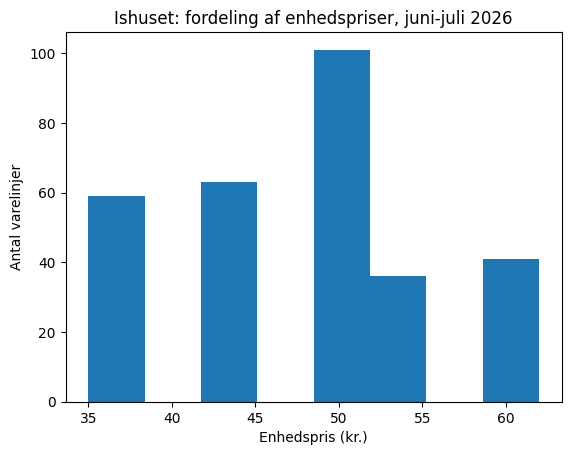

In [16]:
# Fordelingen af enhedspriser, 8 intervaller
plt.hist(df["EnhedsPris"], bins=8)
plt.xlabel("Enhedspris (kr.)")
plt.ylabel("Antal varelinjer")
plt.title("Ishuset: fordeling af enhedspriser, juni-juli 2026")
plt.show()

**Sortér med `sort_values`.** Praktisk, når man vil se de største eller mindste værdier. `ascending=False` giver faldende orden.

In [17]:
# De 5 varelinjer med højeste enhedspris
df.sort_values("EnhedsPris", ascending=False).head()

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris,KampagnePris
2,2130,2026-06-01,Skagen,Vaffel 3 kugler,3,62,49.6
294,2043,2026-07-31,Aalborg C,Vaffel 3 kugler,2,62,49.6
255,2168,2026-07-24,Aalborg C,Vaffel 3 kugler,2,62,49.6
246,2279,2026-07-21,Aalborg C,Vaffel 3 kugler,3,62,49.6
3,2148,2026-06-01,Blokhus,Vaffel 3 kugler,2,62,49.6


**KUN TIL FREMVISNING: underviseren kører denne celle.** Den viser omsætningen pr. dag hen over sommeren. Koden bruger `groupby`, som I først lærer i Anvendt Statistik på 2. semester, så den er ikke pensum i dag. Læg mærke til weekendtoppene: godt isvejr og fri på samme tid.

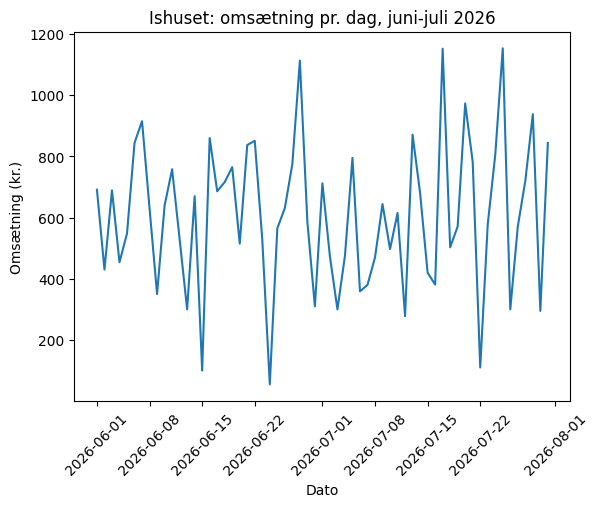

In [18]:
# KUN TIL FREMVISNING (groupby er ikke pensum i dag)
oms_pr_dag = (df["Antal"] * df["EnhedsPris"]).groupby(df["Dato"]).sum()

plt.plot(oms_pr_dag.index, oms_pr_dag.values)
plt.xlabel("Dato")
plt.ylabel("Omsætning (kr.)")
plt.title("Ishuset: omsætning pr. dag, juni-juli 2026")
plt.xticks(rotation=45)
plt.show()

---
## Gruppearbejde 5: Mini-case (14.00 til 14.30)

Din leder skal bruge et hurtigt overblik over sommersalget og har sendt fire opgaver. Alle mønstre findes i **Del 2** ovenfor. Opgaver markeret **(ekstra)** er valgfrie.

In [19]:
# === OPGAVE 1: LØSNING ===
# 1. Opret en ny kolonne i df med navnet Omsætning, beregnet som Antal gange EnhedsPris
df["Omsætning"] = df["Antal"] * df["EnhedsPris"]

# 2. Vis de første 5 rækker, så den nye kolonne kan ses
df.head()

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris,KampagnePris,Omsætning
0,2017,2026-06-01,Aalborg C,Softice,2,45,36.0,90
1,2051,2026-06-01,Skagen,Softice,4,45,36.0,180
2,2130,2026-06-01,Skagen,Vaffel 3 kugler,3,62,49.6,186
3,2148,2026-06-01,Blokhus,Vaffel 3 kugler,2,62,49.6,124
4,2189,2026-06-01,Aalborg C,Vaffel 1 kugle,2,38,30.4,76


In [20]:
# === OPGAVE 2: LØSNING ===
# 1. Udvælg de rækker, hvor Vare er "Softice"
softice = df[df["Vare"] == "Softice"]

# 2. Vis summen af Omsætning for disse rækker
print(f"Samlet omsætning for Softice: {softice['Omsætning'].sum()} kr.")

# 3. Vis gennemsnittet af Omsætning for disse rækker
print(f"Gennemsnitlig omsætning pr. Softice-varelinje: {softice['Omsætning'].mean():.1f} kr.")

Samlet omsætning for Softice: 6795 kr.
Gennemsnitlig omsætning pr. Softice-varelinje: 107.9 kr.


In [21]:
# === OPGAVE 3: LØSNING ===
blokhus = df[df["Butik"] == "Blokhus"]
print(f"Blokhus: gennemsnitlig omsætning pr. varelinje = {blokhus['Omsætning'].mean():.1f} kr.")

# De tilsvarende to linjer for Skagen:
skagen = df[df["Butik"] == "Skagen"]
print(f"Skagen: gennemsnitlig omsætning pr. varelinje = {skagen['Omsætning'].mean():.1f} kr.")

Blokhus: gennemsnitlig omsætning pr. varelinje = 131.0 kr.
Skagen: gennemsnitlig omsætning pr. varelinje = 123.0 kr.


**Svar med tekst (FACIT):** Blokhus sælger størst pr. varelinje: **131,0 kr. mod Skagens 123,0 kr.**

**(ekstra)** Alle fire butikker: Blokhus 131,0, Løkken 124,6, Skagen 123,0, Aalborg C 117,9 kr. Flagskibet i Aalborg har flest varelinjer men den mindste gennemsnitslinje. Et rimeligt bud: turister ved kysten køber flere og dyrere is pr. ekspedition end byens kunder.

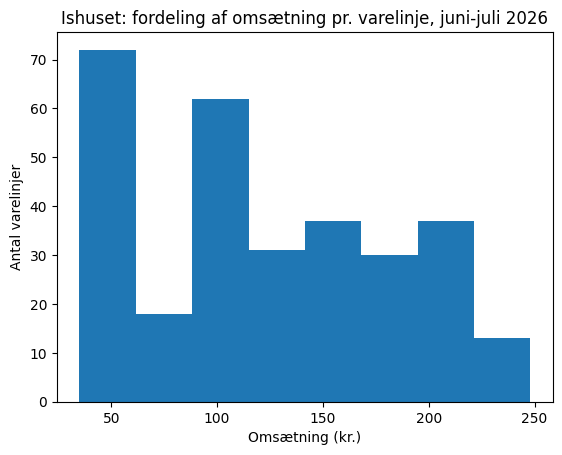

In [22]:
# === OPGAVE 4: LØSNING ===
plt.hist(df["Omsætning"], bins=8)
plt.xlabel("Omsætning (kr.)")
plt.ylabel("Antal varelinjer")
plt.title("Ishuset: fordeling af omsætning pr. varelinje, juni-juli 2026")
plt.show()

**Svar med tekst (FACIT):** Eksempel på godkendt svar: De fleste varelinjer ligger mellem ca. 35 og 150 kr., og kun få store varelinjer når op over 200 kr. (fordelingen er højreskæv). Enhver sætning, der korrekt beskriver, hvor tyngden ligger, godkendes.

In [23]:
# === OPGAVE 5 (ekstra): LØSNING ===
# Vis de 10 varelinjer med størst Omsætning
df.sort_values("Omsætning", ascending=False).head(10)

,SalgsId,Dato,Butik,Vare,Antal,EnhedsPris,KampagnePris,Omsætning
249,2198,2026-07-23,Blokhus,Vaffel 3 kugler,4,62,49.6,248
225,2181,2026-07-18,Blokhus,Vaffel 3 kugler,4,62,49.6,248
57,2239,2026-06-12,Aalborg C,Vaffel 3 kugler,4,62,49.6,248
238,2273,2026-07-20,Aalborg C,Vaffel 3 kugler,4,62,49.6,248
180,2084,2026-07-09,Blokhus,Vaffel 3 kugler,4,62,49.6,248
105,2032,2026-06-23,Blokhus,Vaffel 3 kugler,4,62,49.6,248
198,2169,2026-07-13,Skagen,Vaffel 3 kugler,4,62,49.6,248
80,2159,2026-06-18,Blokhus,Vaffel 3 kugler,4,62,49.6,248
276,2190,2026-07-27,Aalborg C,Vaffel 3 kugler,4,62,49.6,248
19,2092,2026-06-05,Løkken,Vaffel 3 kugler,4,62,49.6,248


---
## Inden eksamen: hvad du lige har gjort

Mini-casen svarer til opgaverne i case-eksamen kl. 15.30:

1. Indlæse og inspicere en datafil (gruppearbejde 4, opgave 1)
2. Oprette en beregnet kolonne (opgave 1 ovenfor)
3. Slå en bestemt række op via SalgsId (mønstret fra Del 2)
4. Filtrere og beregne sum og gennemsnit (opgave 2 ovenfor)
5. Histogram med aksetekster og overskrift (opgave 4 ovenfor)

Til eksamen får du et **nyt datasæt fra en anden virksomhed**. Kolonnenavnene er ikke de samme som i Ishuset: start derfor altid med `head()`, og brug de kolonnenavne, du ser der. Denne notebook må være åben under eksamen.